In [4]:
import pandas as pd
import numpy as np
from google.colab import drive

In [5]:
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')
data.head()

Mounted at /content/drive


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
data.shape

(32581, 12)

In [7]:
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [8]:
data['person_emp_length'].fillna(data['person_emp_length'].mean(), inplace=True)
data['loan_int_rate'].fillna(data['loan_int_rate'].mean(), inplace=True)
data

/tmp/ipykernel_5880/2625540341.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['person_emp_length'].fillna(data['person_emp_length'].mean(), inplace=True)
/tmp/ipykernel_5880/2625540341.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [9]:
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
data_num = pred_data.select_dtypes(exclude= object)
data_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_emp_length           32581 non-null  float64
 3   loan_amnt                   32581 non-null  int64  
 4   loan_int_rate               32581 non-null  float64
 5   loan_status                 32581 non-null  int64  
 6   loan_percent_income         32581 non-null  float64
 7   cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 2.0 MB


In [13]:
data_cat = pred_data.select_dtypes(include= object)
data_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   person_home_ownership  32581 non-null  object
 1   loan_intent            32581 non-null  object
 2   loan_grade             32581 non-null  object
dtypes: object(3)
memory usage: 763.7+ KB


# EDA

EDA for Numerical Features (data_num):


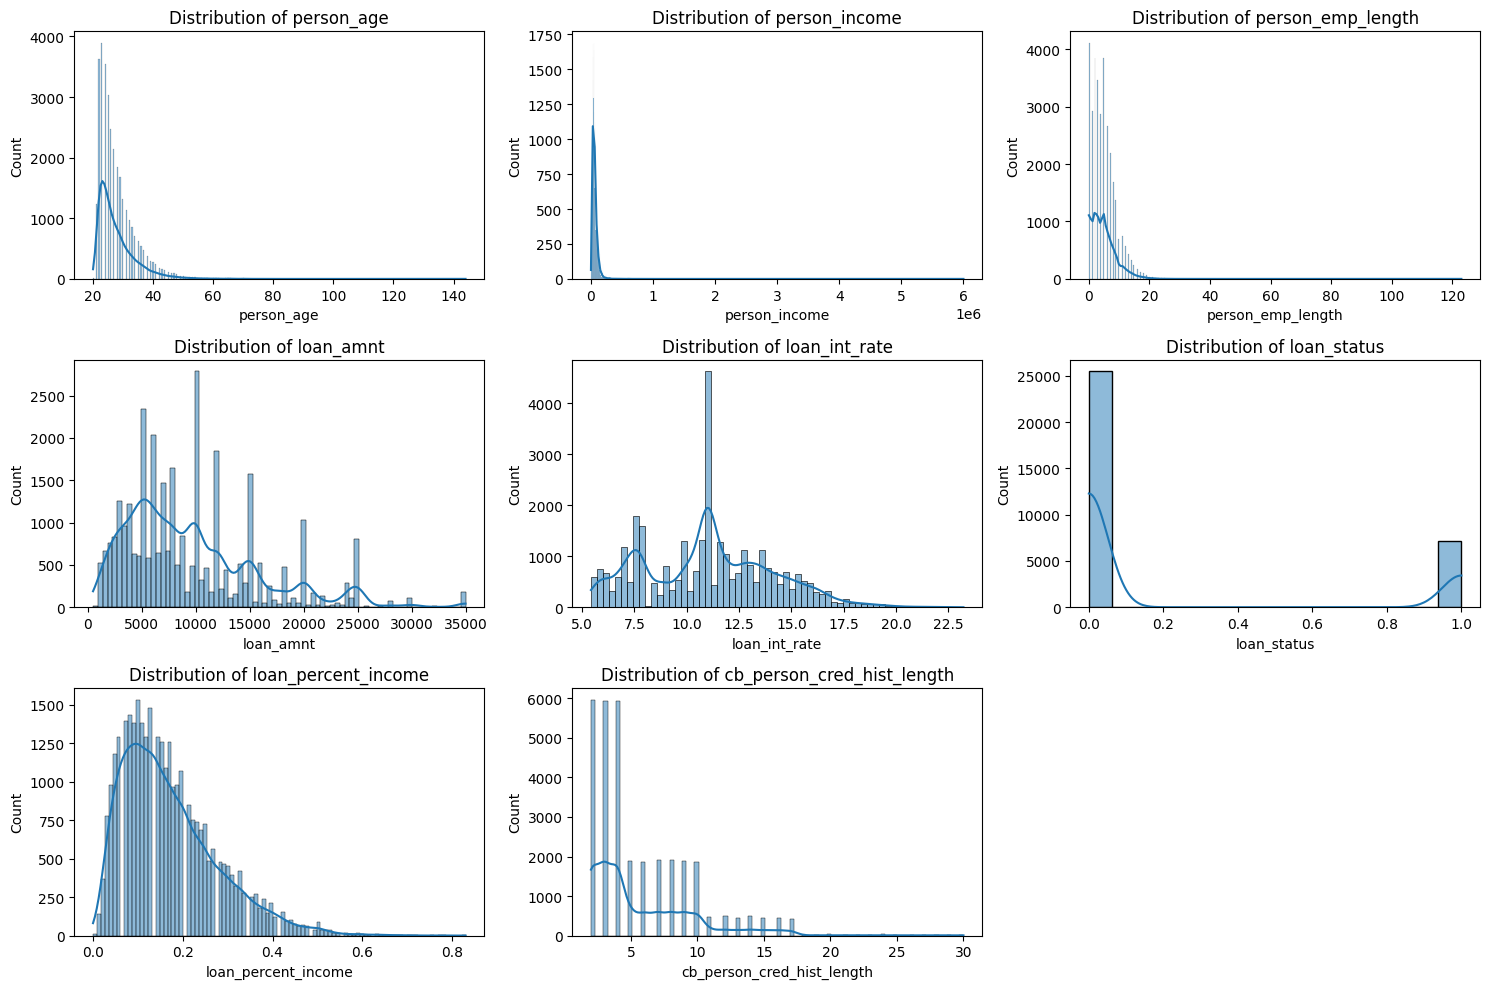

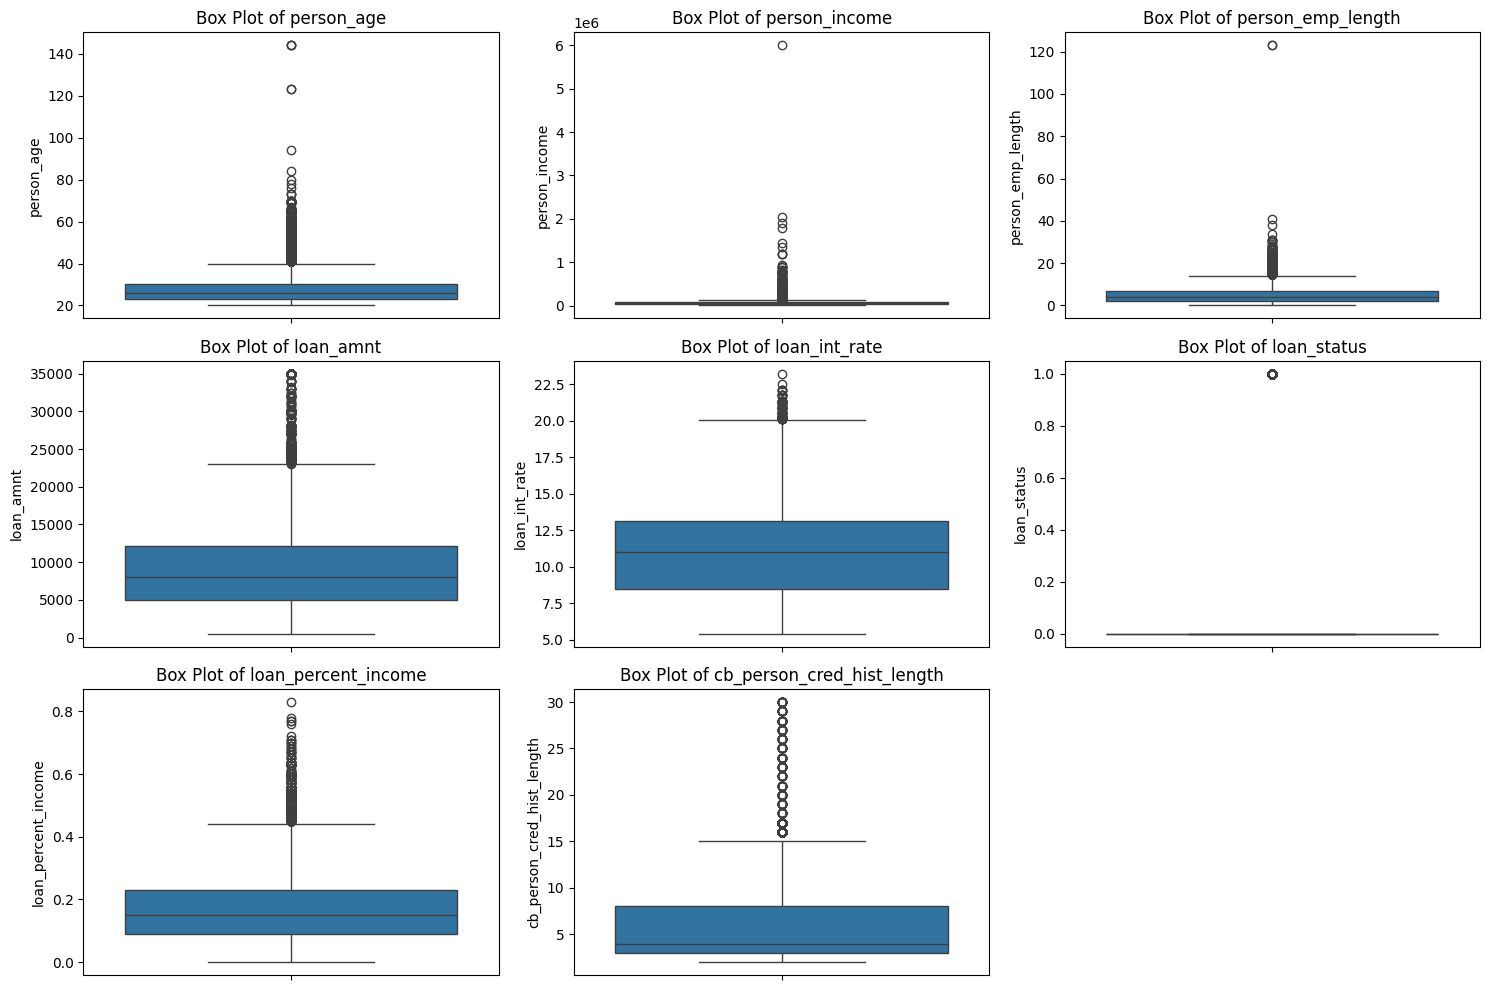

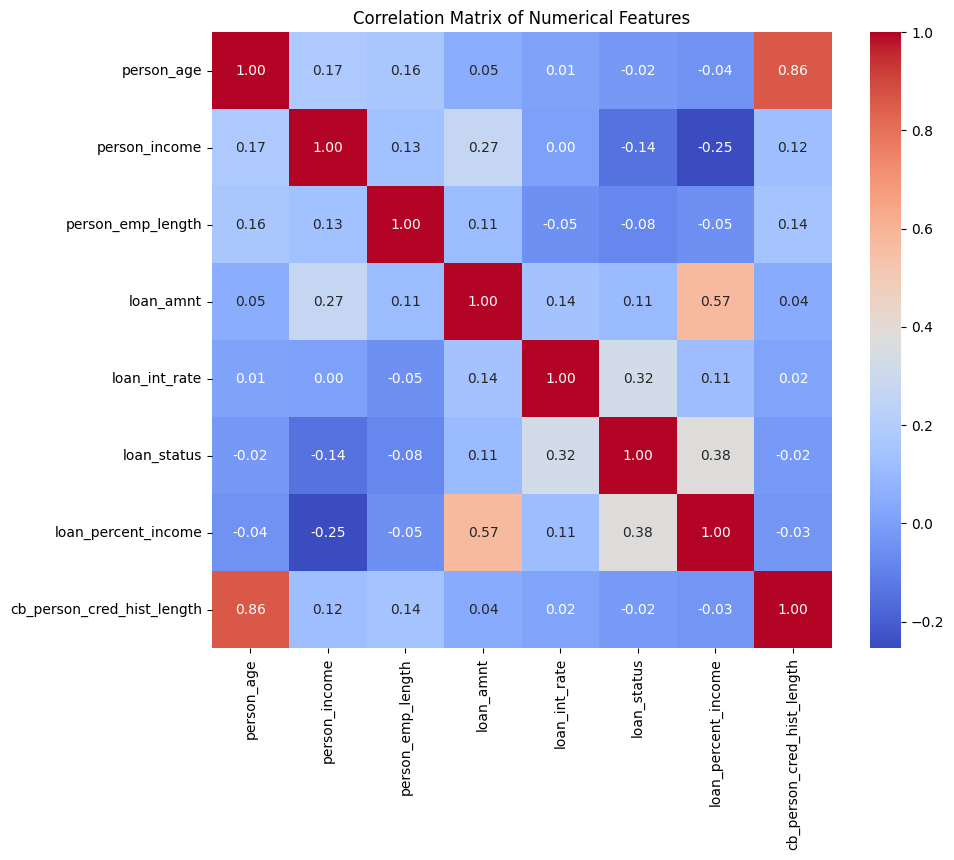


EDA for Categorical Features (data_cat):


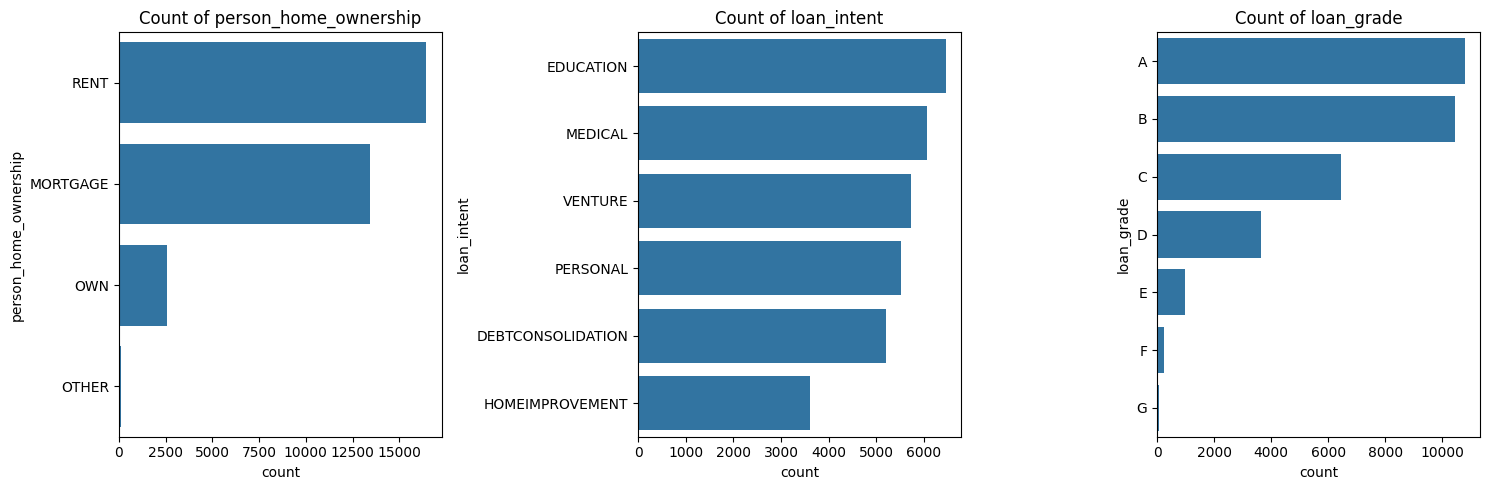

In [92]:
print('EDA for Numerical Features (data_num):')
# Histograms for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(data_num.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(data_num[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(data_num.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=data_num[column])
    plt.title(f'Box Plot of {column}')
    plt.tight_layout()
plt.show()

# Correlation Matrix for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(data_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


print('\nEDA for Categorical Features (data_cat):')
# Count plots for categorical features
plt.figure(figsize=(15, 5))
for i, column in enumerate(data_cat.columns):
    plt.subplot(1, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.countplot(y=data_cat[column], order = data_cat[column].value_counts().index)
    plt.title(f'Count of {column}')
    plt.tight_layout()
plt.show()

# Target Variable

In [82]:
pred_data = data.drop('cb_person_default_on_file', axis=1)
y = data['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

# Scaling

In [84]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler()

# Apply StandardScaler to selected numerical feature columns
data_num_scaled = pd.DataFrame(std_scaler.fit_transform(data_num), columns=data_num.columns)
# end

# One hot Encoding

In [85]:
data_dum = pd.DataFrame()
for c in data_cat.columns:
    dummy = pd.get_dummies(data_cat[c], prefix=c, dtype=int)
    dummy_sum = dummy.sum(axis=0)
    col_to_drop = dummy_sum.idxmax()
    dummy = dummy.drop(columns=[col_to_drop])
    data_dum = pd.concat([data_dum, dummy], axis=1)
# end
data_dum.head()

,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,loan_intent_DEBTCONSOLIDATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1,0,0,1,0,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,1,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,1,0,0,0,0


In [69]:
X = pd.concat([data_num_scaled, data_dum], axis=1)
X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,-0.903374,-0.114143,28.935738,4.019404,1.625251,1.893069,3.931411,-0.691554,0,0,...,0,0,1,0,0,0,1,0,0,0
1,-1.060904,-0.911147,0.051481,-1.358650,0.041636,-0.528243,-0.657458,-0.938167,0,0,...,0,0,0,0,1,0,0,0,0,0
2,-0.430783,-0.911147,-0.927646,-0.646849,0.603041,1.893069,3.744110,-0.691554,1,0,...,0,1,0,0,0,1,0,0,0,0
3,-0.745843,-0.009274,-0.193301,4.019404,1.368887,1.893069,3.369508,-0.938167,0,0,...,0,1,0,0,0,1,0,0,0,0
4,-0.588313,-0.188358,0.785826,4.019404,1.057357,1.893069,3.556809,-0.444942,0,0,...,0,1,0,0,0,1,0,0,0,0


In [87]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=10,
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train_res).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())

Original data:
cb_person_default_on_file
0    26836
1     5745
Name: count, dtype: int64

Training data:
cb_person_default_on_file
1    21468
0    21468
Name: count, dtype: int64

Testing data:
cb_person_default_on_file
0    5368
1    1149
Name: count, dtype: int64


In [71]:
X.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32581, 22), (26064, 22), (6517, 22), (26064,), (6517,))

In [88]:
X_train_res.shape, X_test.shape, y_train_res.shape, y_test.shape

((42936, 22), (6517, 22), (42936,), (6517,))

In [89]:
from sklearn.decomposition import PCA

pca = PCA(n_components=22)

df_scaled_pca = pd.DataFrame(
    pca.fit_transform(X)
)

# Model

In [90]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

models = [
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    DecisionTreeClassifier(max_leaf_nodes=3),
    DecisionTreeClassifier(max_leaf_nodes=10),
    DecisionTreeClassifier(max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1)
]

# Evaluation metrics

RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      5368
           1       0.50      0.94      0.65      1149

    accuracy                           0.82      6517
   macro avg       0.74      0.87      0.77      6517
weighted avg       0.90      0.82      0.84      6517



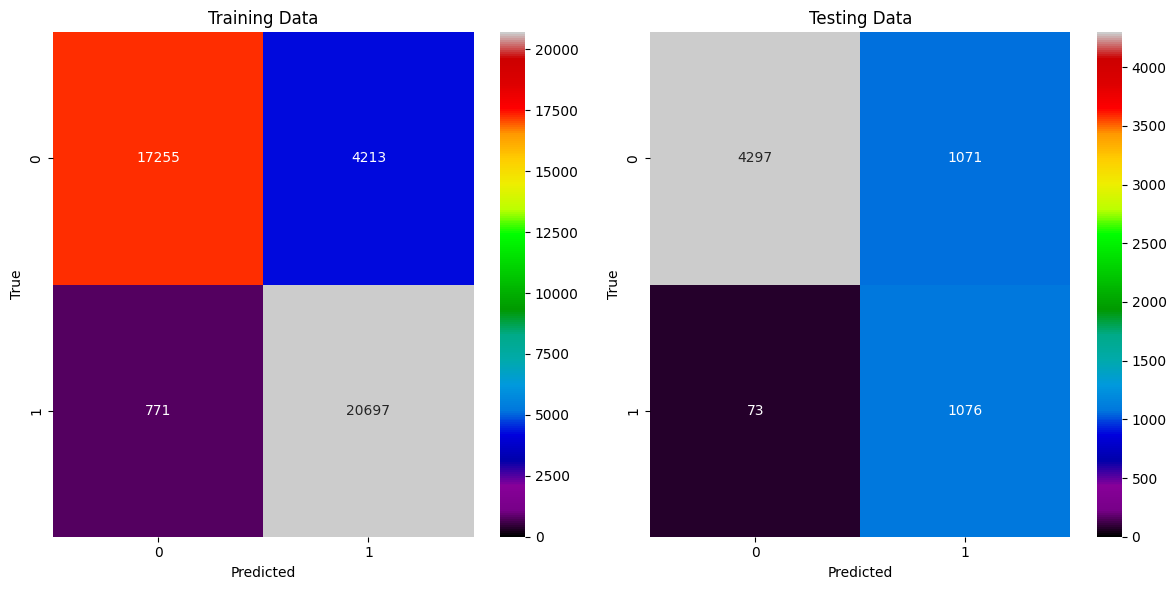

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       1.00      0.79      0.88      5368
           1       0.50      0.98      0.67      1149

    accuracy                           0.83      6517
   macro avg       0.75      0.89      0.77      6517
weighted avg       0.91      0.83      0.84      6517



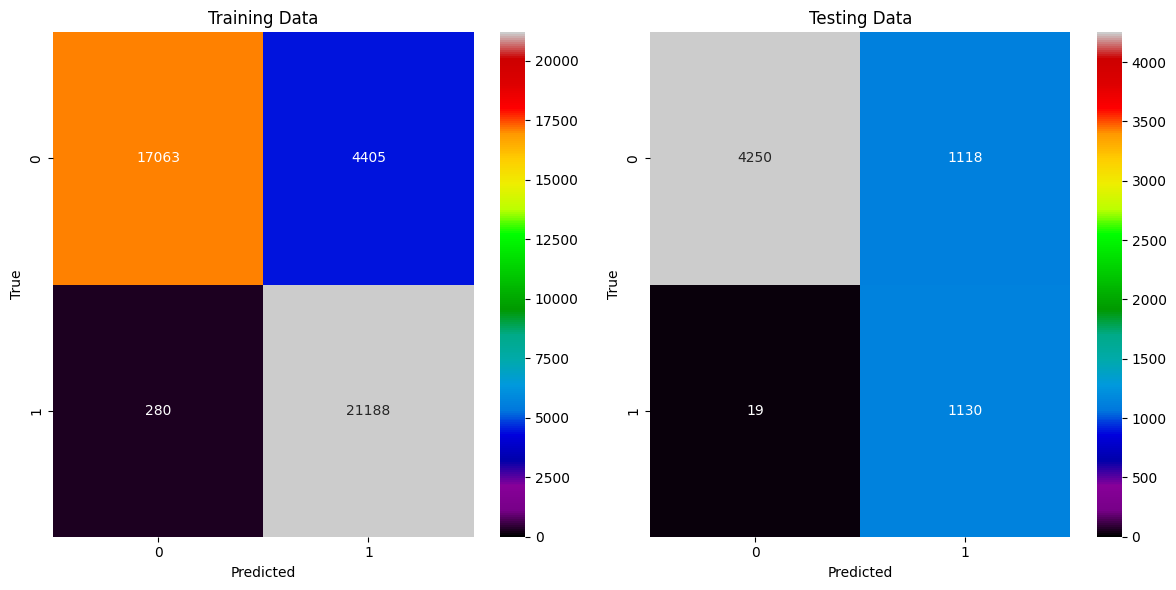

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       1.00      0.79      0.88      5368
           1       0.50      0.99      0.67      1149

    accuracy                           0.83      6517
   macro avg       0.75      0.89      0.77      6517
weighted avg       0.91      0.83      0.84      6517



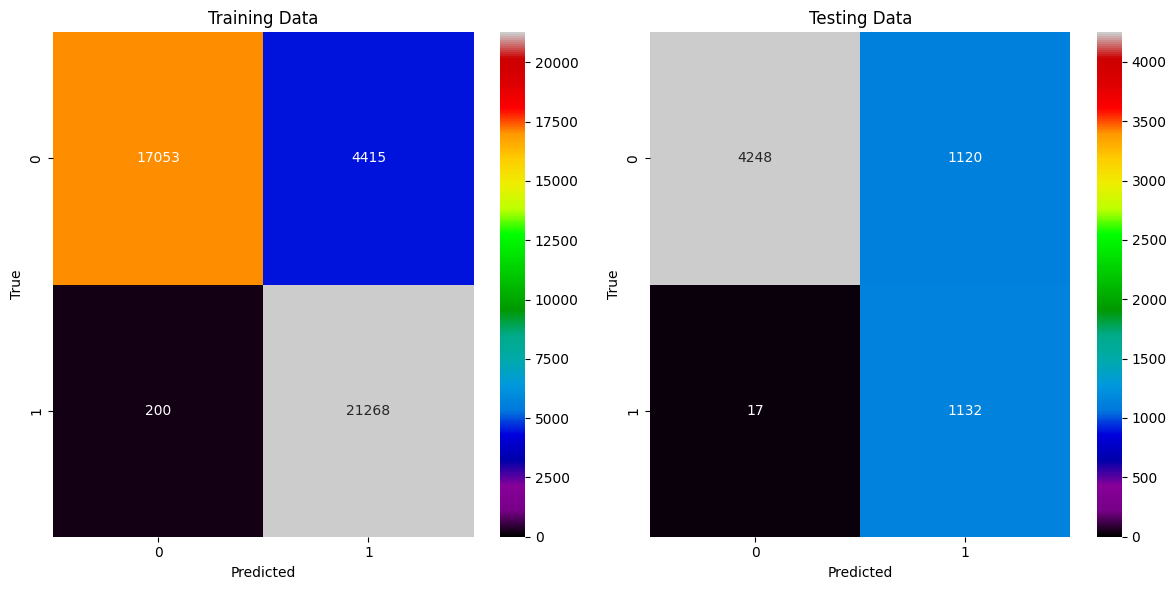

DecisionTreeClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.99      0.77      0.86      5368
           1       0.47      0.96      0.63      1149

    accuracy                           0.80      6517
   macro avg       0.73      0.86      0.75      6517
weighted avg       0.90      0.80      0.82      6517



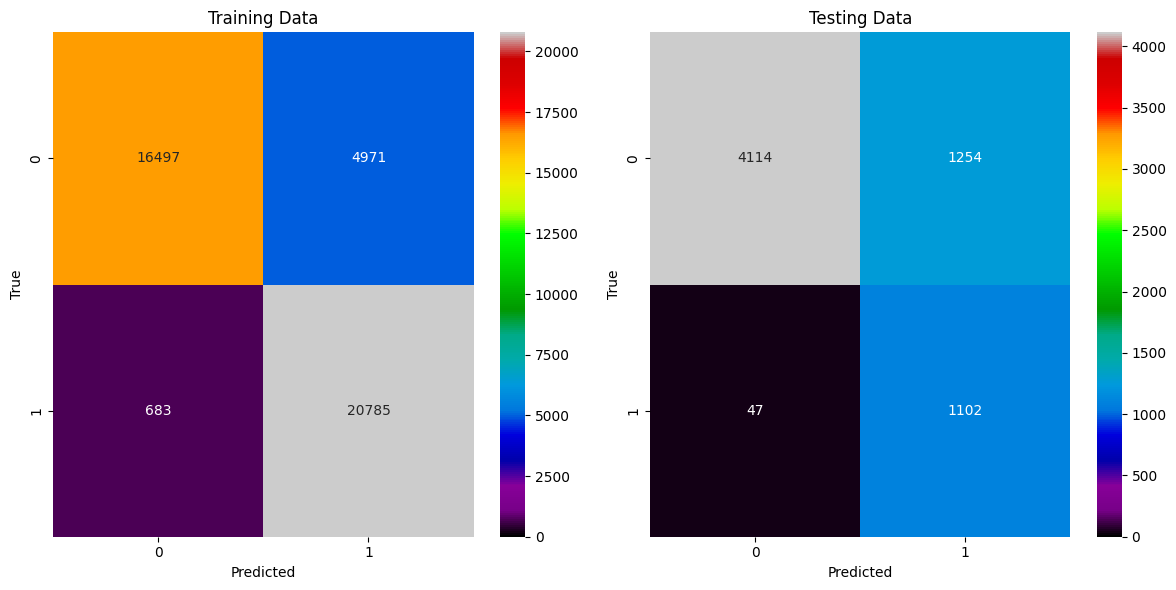

DecisionTreeClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       1.00      0.79      0.88      5368
           1       0.50      1.00      0.67      1149

    accuracy                           0.83      6517
   macro avg       0.75      0.89      0.78      6517
weighted avg       0.91      0.83      0.84      6517



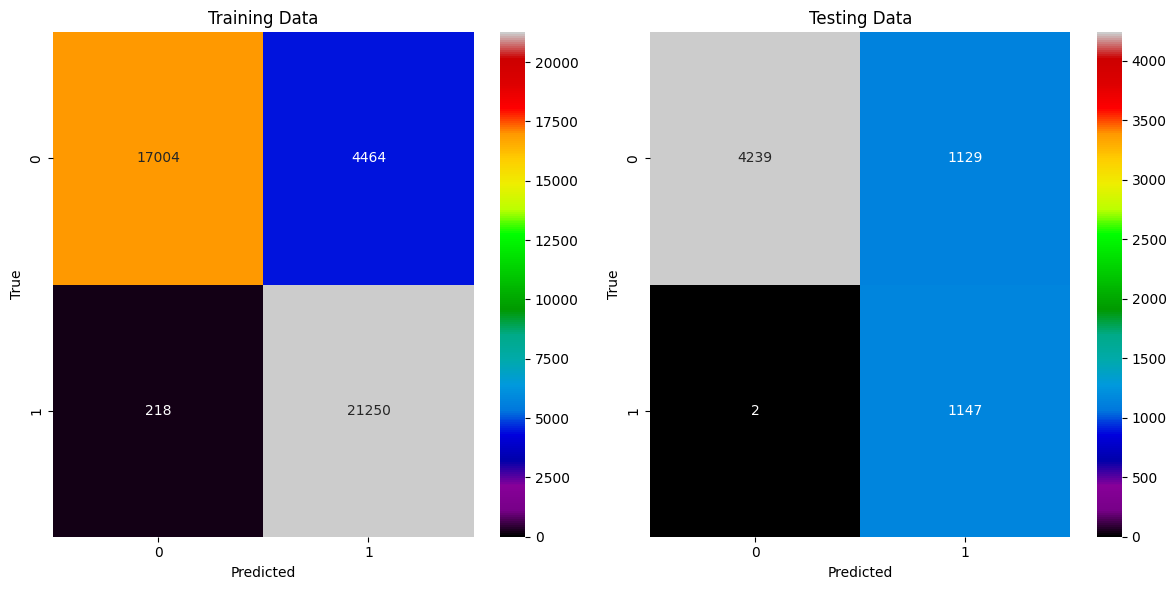

DecisionTreeClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       1.00      0.79      0.88      5368
           1       0.50      1.00      0.67      1149

    accuracy                           0.83      6517
   macro avg       0.75      0.89      0.78      6517
weighted avg       0.91      0.83      0.84      6517



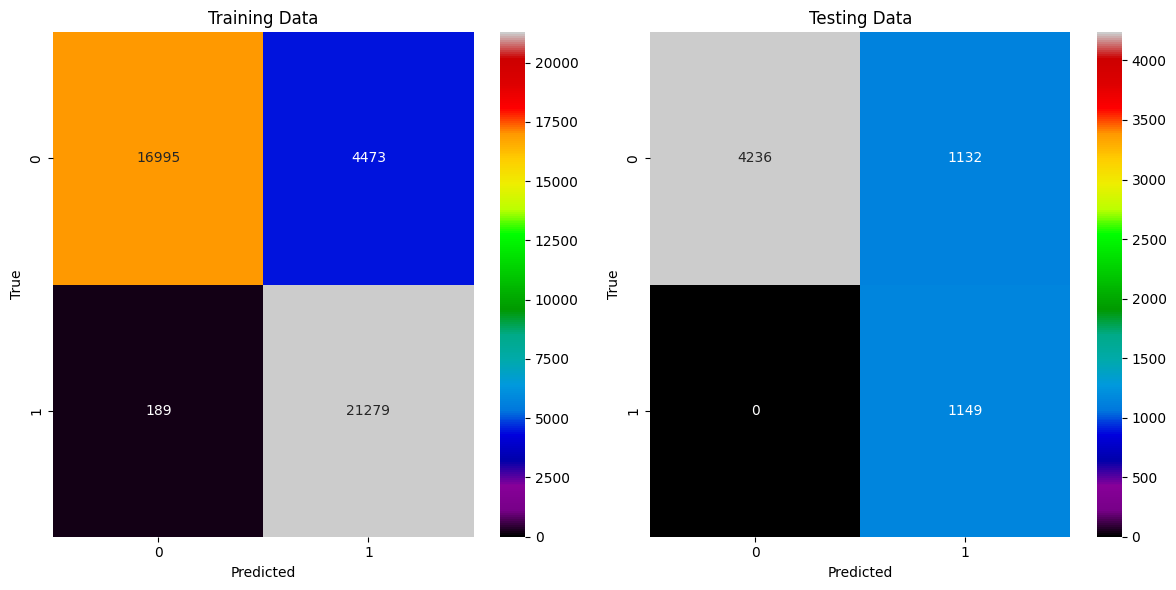

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.99      0.80      0.88      5368
           1       0.50      0.95      0.66      1149

    accuracy                           0.83      6517
   macro avg       0.75      0.88      0.77      6517
weighted avg       0.90      0.83      0.84      6517



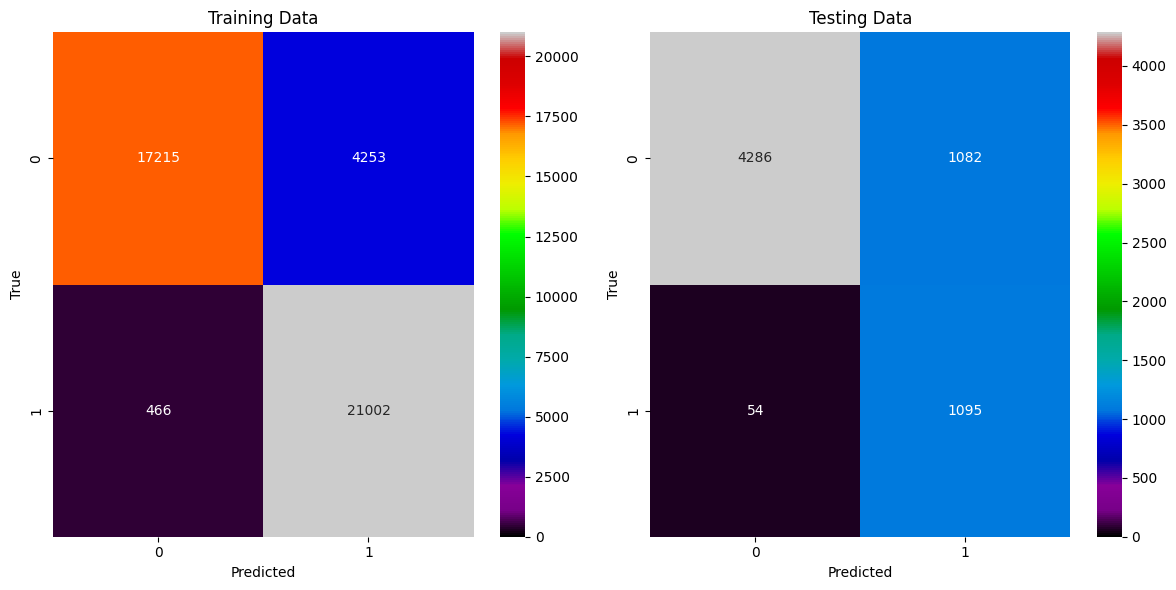

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.99      0.80      0.88      5368
           1       0.50      0.95      0.66      1149

    accuracy                           0.83      6517
   macro avg       0.74      0.88      0.77      6517
weighted avg       0.90      0.83      0.84      6517



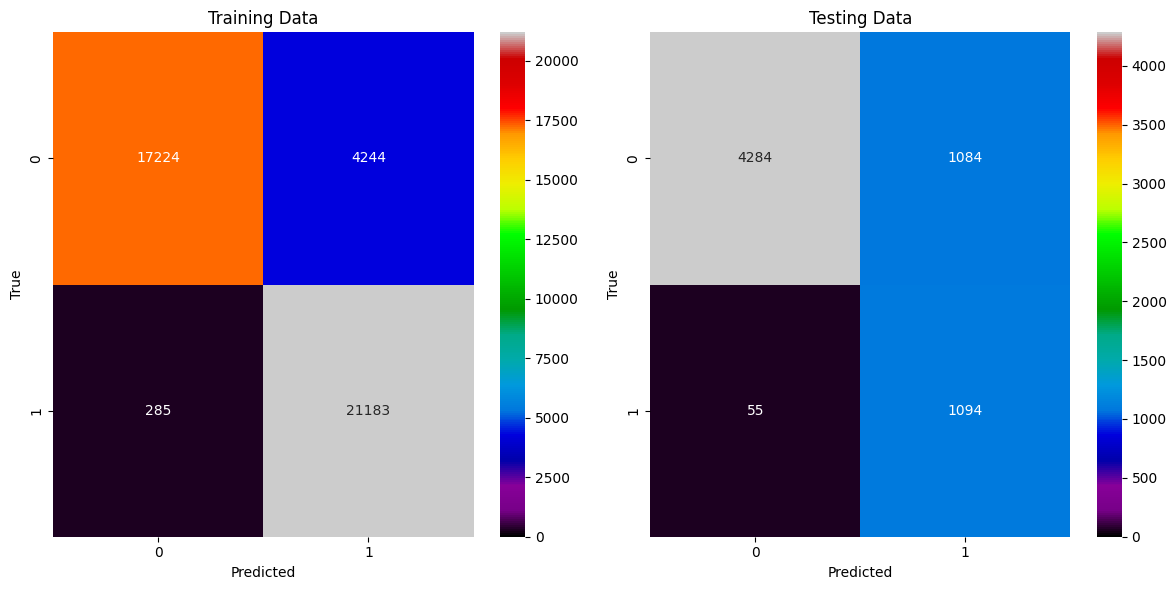

GradientBoostingClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.99      0.80      0.88      5368
           1       0.50      0.95      0.66      1149

    accuracy                           0.83      6517
   macro avg       0.74      0.88      0.77      6517
weighted avg       0.90      0.83      0.84      6517



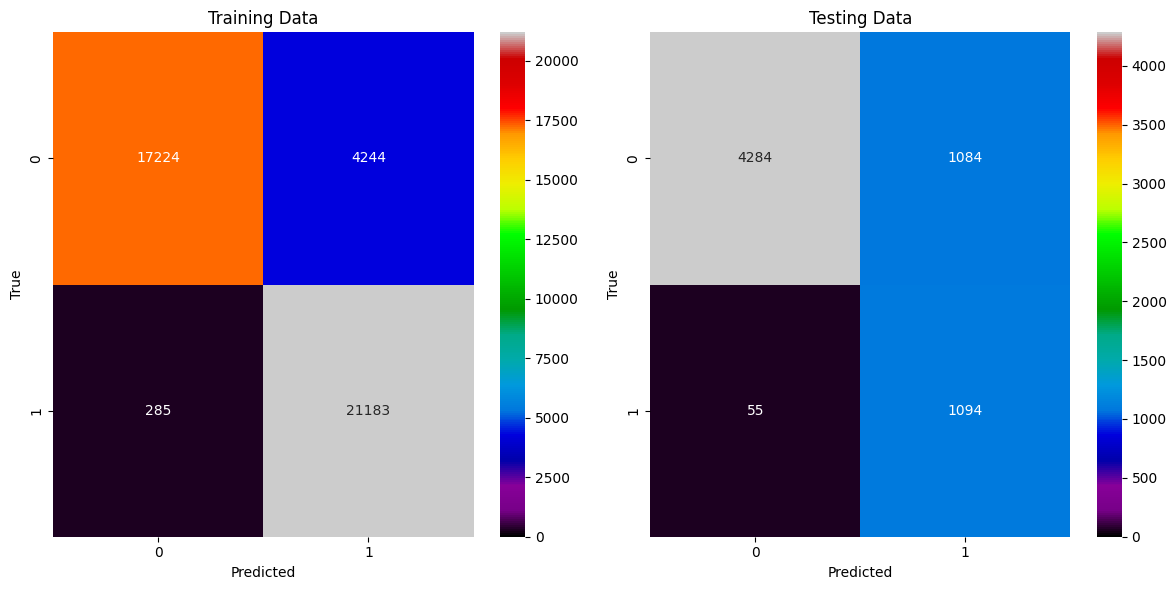

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:40:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=3, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.97      0.81      0.88      5368
           1       0.50      0.89      0.64      1149

    accuracy                           0.82      6517
   macro avg       0.74      

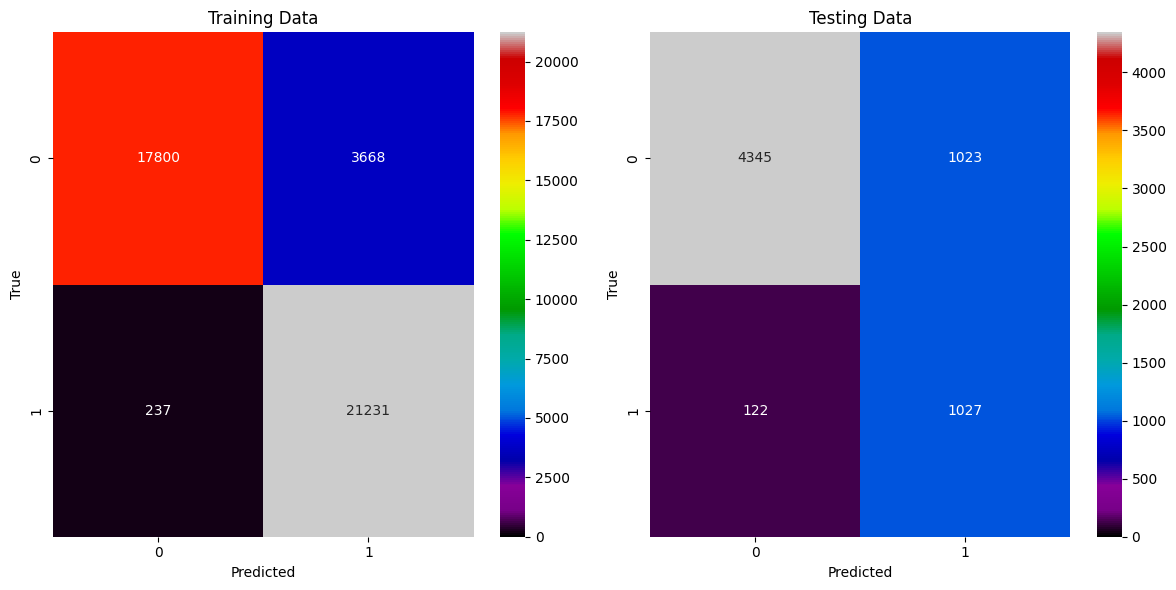

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:40:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=10, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.97      0.81      0.88      5368
           1       0.50      0.89      0.64      1149

    accuracy                           0.82      6517
   macro avg       0.74     

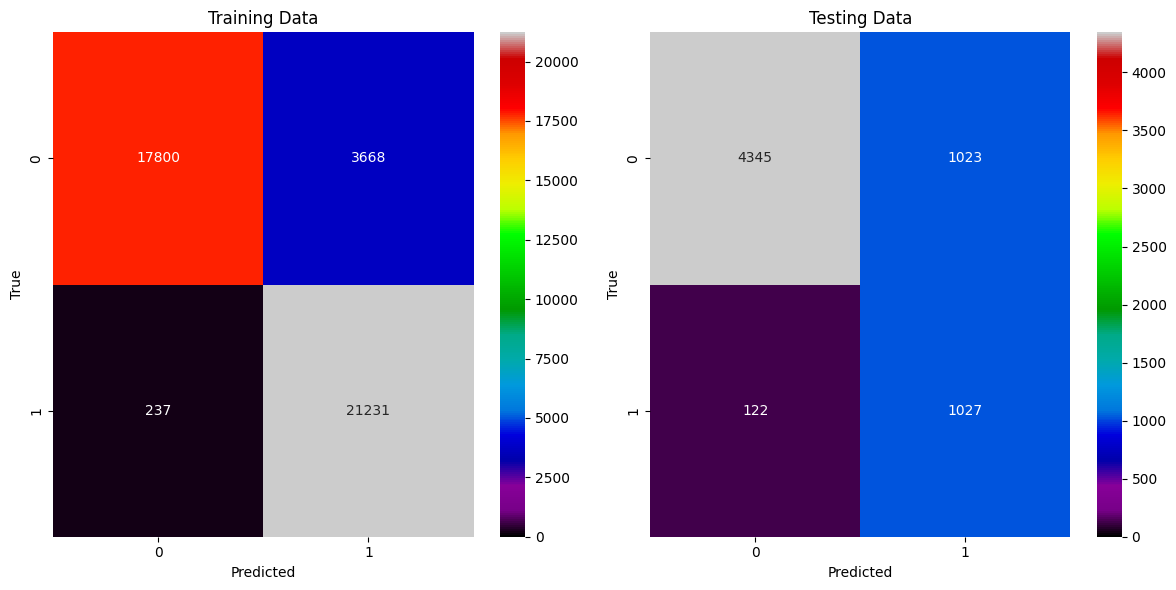

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:40:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=30, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.97      0.81      0.88      5368
           1       0.50      0.89      0.64      1149

    accuracy                           0.82      6517
   macro avg       0.74     

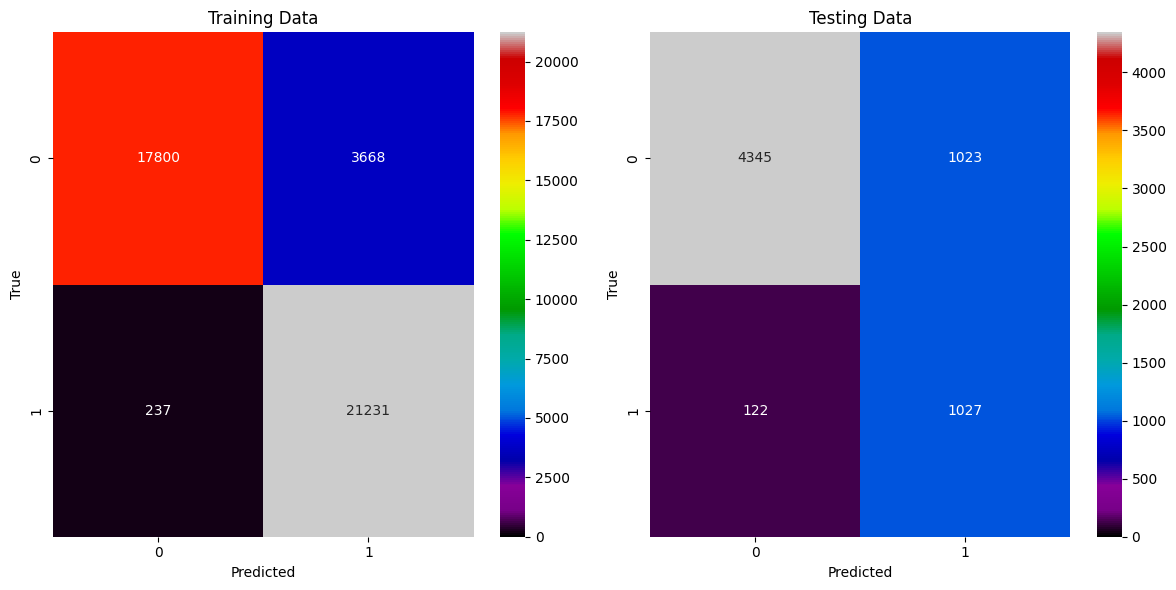

AdaBoostClassifier(learning_rate=0.1, n_estimators=100)
              precision    recall  f1-score   support

           0       1.00      0.75      0.86      5368
           1       0.46      0.99      0.63      1149

    accuracy                           0.79      6517
   macro avg       0.73      0.87      0.74      6517
weighted avg       0.90      0.79      0.82      6517



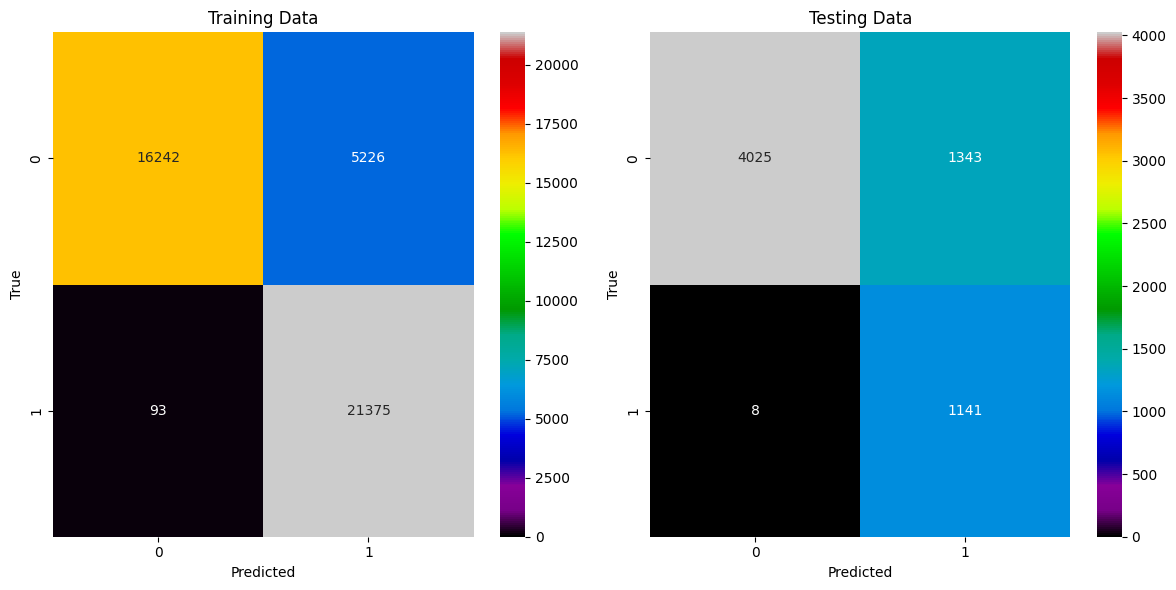

In [91]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

for m in models:
    m.fit(X_train_res, y_train_res)
    y_train_pred = m.predict(X_train_res)
    y_test_pred = m.predict(X_test)

    print(m)
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train_res, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0], cmap='nipy_spectral')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1], cmap='nipy_spectral')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()

In [93]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

model_to_evaluate = models[5] # Change this to select a different model

y_score = model_to_evaluate.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_score)
auroc = roc_auc_score(y_test, y_score)
print("AUPRC:", auprc)
print("AUROC:", auroc)

AUPRC: 0.49441446542033435
AUROC: 0.890039482268648
